In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer
import torch as pt
import re
import os
from sklearn.model_selection import train_test_split

# Loading of Datasets

In [ ]:
df_welfake = pd.read_csv("../../Datasets/saurabhshahane/fake-news-classification/versions/77/WELFake_Dataset.csv")

print(df_welfake.head())

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [3]:
df_aadyasingh55 = pd.read_csv("../../Datasets/aadyasingh55/fake-news-classification/versions/1/merged.csv")

df_aadyasingh55.head()

,Unnamed: 0,title,text,label
0,0,Palestinians switch off Christmas lights in Be...,"RAMALLAH, West Bank (Reuters) - Palestinians s...",1
1,1,China says Trump call with Taiwan president wo...,BEIJING (Reuters) - U.S. President-elect Donal...,1
2,2,FAIL! The Trump Organization’s Credit Score W...,While the controversy over Trump s personal ta...,0
3,3,Zimbabwe military chief's China trip was norma...,BEIJING (Reuters) - A trip to Beijing last wee...,1
4,4,THE MOST UNCOURAGEOUS PRESIDENT EVER Receives ...,There has never been a more UNCOURAGEOUS perso...,0


In [4]:
df_fakenewsnet = pd.read_csv("../../Datasets/algord/fake-news/versions/1/FakeNewsNet.csv")

df_fakenewsnet = df_fakenewsnet.rename(columns={'real':'label'})

df_fakenewsnet.head()

,title,news_url,source_domain,tweet_num,label
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


In [5]:
df_fake_news_detection = pd.read_csv("../../Datasets/fake-news-detection-dataset-English/merged.csv")

df_fake_news_detection.head()

,Unnamed: 0,title,text,subject,date,label
0,2619,Ex-CIA head says Trump remarks on Russia inter...,Former CIA director John Brennan on Friday cri...,politicsNews,"July 22, 2017",1
1,16043,YOU WON’T BELIEVE HIS PUNISHMENT! HISPANIC STO...,How did this man come to OWN this store? There...,Government News,"Jun 19, 2017",0
2,876,Federal Reserve governor Powell's policy views...,President Donald Trump on Thursday tapped Fede...,politicsNews,"November 2, 2017",1
3,19963,SCOUNDREL HILLARY SUPPORTER STARTS “TrumpLeaks...,Hillary Clinton ally David Brock is offering t...,left-news,"Sep 17, 2016",0
4,10783,NANCY PELOSI ARROGANTLY DISMISSES Questions on...,Pleading ignorance is a perfect ploy for Nancy...,politics,"May 26, 2017",0


In [6]:
df_news_true = pd.read_csv("../../Datasets/News-_dataset/Fake.csv")
df_news_false = pd.read_csv("../../Datasets/News-_dataset/True.csv")

# Assigning labels then merging
df_news_true['label'] = 1
df_news_false['label'] = 0

df_news = pd.concat([df_news_true, df_news_false])
df_news.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [7]:
df_truth_seeker = pd.read_csv("../../Datasets/TruthSeeker2023/Truth_Seeker_Model_Dataset.csv")

# For this dataset, it does not appear that it is very consistent, regardless for puposes of analysis, BinaryNumTarget will be used as the label column

df_truth_seeker = df_truth_seeker.rename(columns={'BinaryNumTarget':'label'})

df_truth_seeker.head()

,Unnamed: 0,author,statement,target,label,manual_keywords,tweet,5_label_majority_answer,3_label_majority_answer
0,0,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",@POTUS Biden Blunders - 6 Month Update\n\nInfl...,Mostly Agree,Agree
1,1,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",@S0SickRick @Stairmaster_ @6d6f636869 Not as m...,NO MAJORITY,Agree
2,2,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",THE SUPREME COURT is siding with super rich pr...,Agree,Agree
3,3,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",@POTUS Biden Blunders\n\nBroken campaign promi...,Mostly Agree,Agree
4,4,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",@OhComfy I agree. The confluence of events rig...,Agree,Agree


## Dataset properties

In [8]:
df_names = ['df_welfake', 'df_aadyasingh55', 'df_fakenewsnet', 'df_fake_news_detection', 'df_news', 'df_truth_seeker']

In [9]:
for df in df_names:
    print(f"\nDataset: {df}")
    print(f"Dataset Shape: {eval(df).shape}")

    print("\nMissing values")
    print(eval(df).isnull().sum())

    print("\nClass balance")
    print(eval(df)['label'].value_counts())
    print(eval(df)['label'].value_counts(normalize=True))

    print(f"\nDuplicate Rows: {eval(df).duplicated().sum()}")


Dataset: df_welfake
Dataset Shape: (72134, 4)

Missing values
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

Class balance
label
1    37106
0    35028
Name: count, dtype: int64
label
1    0.514404
0    0.485596
Name: proportion, dtype: float64

Duplicate Rows: 0

Dataset: df_aadyasingh55
Dataset Shape: (40587, 4)

Missing values
Unnamed: 0    0
title         0
text          0
label         0
dtype: int64

Class balance
label
1    21924
0    18663
Name: count, dtype: int64
label
1    0.540173
0    0.459827
Name: proportion, dtype: float64

Duplicate Rows: 0

Dataset: df_fakenewsnet
Dataset Shape: (23196, 5)

Missing values
title              0
news_url         330
source_domain    330
tweet_num          0
label              0
dtype: int64

Class balance
label
1    17441
0     5755
Name: count, dtype: int64
label
1    0.751897
0    0.248103
Name: proportion, dtype: float64

Duplicate Rows: 137

Dataset: df_fake_news_detection
Dataset Shape: (44267,

/var/folders/dc/77k6d3lx0g383jd_j5xfbknm0000gn/T/ipykernel_80285/1756893419.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=eval(df), palette='viridis')
/var/folders/dc/77k6d3lx0g383jd_j5xfbknm0000gn/T/ipykernel_80285/1756893419.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=eval(df), palette='viridis')
/var/folders/dc/77k6d3lx0g383jd_j5xfbknm0000gn/T/ipykernel_80285/1756893419.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=eval(df), palette='viridis')
/var/fo

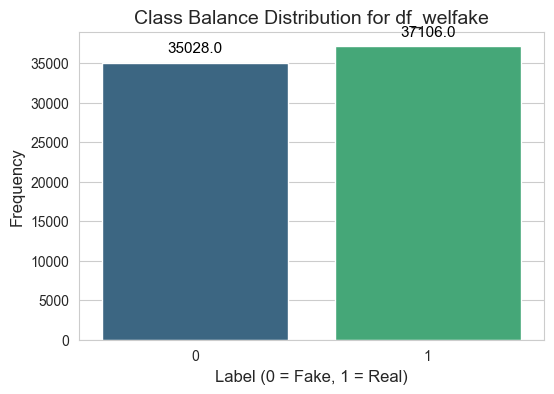

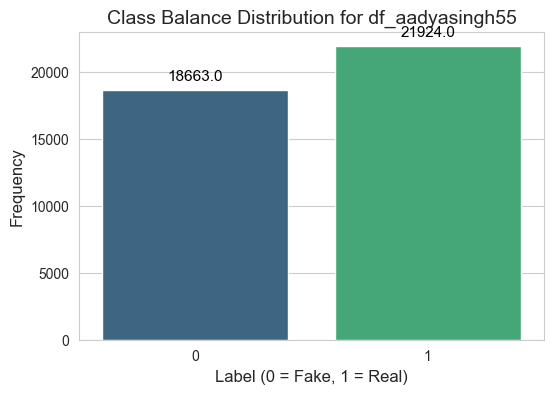

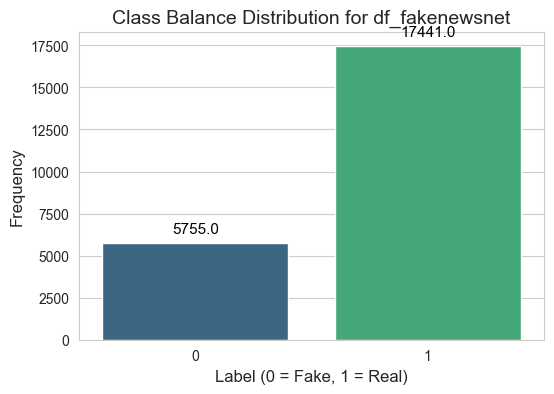

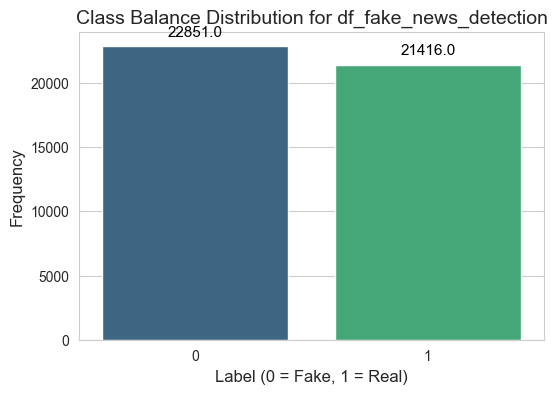

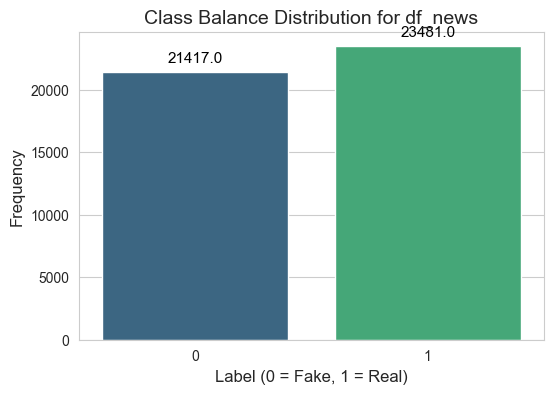

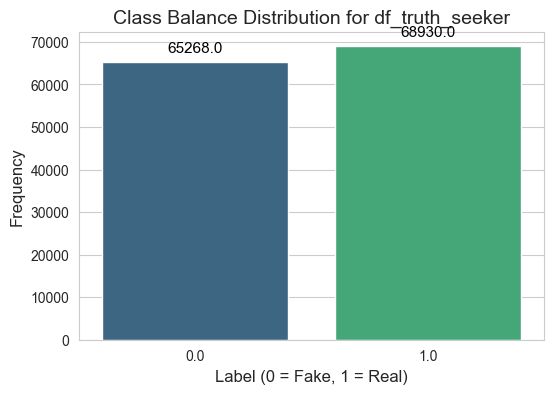

In [10]:
for df in df_names:
    sns.set_style("whitegrid")

    plt.figure(figsize=(6, 4))
    ax = sns.countplot(x='label', data=eval(df), palette='viridis')

    plt.title(f'Class Balance Distribution for {df}', fontsize=14)
    plt.xlabel('Label (0 = Fake, 1 = Real)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    # plt.ylim(0, 42000)

    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5),
                    textcoords='offset points')

## Processing and cleaning the dataset
- Combining title and text as some columns are missing one (WELFake), also make integration with other datasets easier
- Drop unnecessary columns
- Clean combined textual data by removing non-unicode characters (emojis), URLs and phone numbers.

### Dataset status
- WELFake, 'aadyasingh55', Fake News Detection, 'News': Title, Text columns to be merged
- Will not be proceeding with TruthSeeker for now, dataset seems messy
- FakeNewsNet will be used with title column only.

In [11]:
# Datasets with distinct title and text columns

distinct_text_dfs = {
    'df_welfake', 'df_aadyasingh55', 'df_fake_news_detection', 'df_news'
}

In [12]:
for df in distinct_text_dfs:
    print(f"\nProcessing dataset: {df}")
    # Combine title and text
    eval(df)['combined_text'] = eval(df)['title'].fillna('') + ' ' + eval(df)['text'].fillna('')
    eval(df)['combined_text'] = eval(df)['combined_text'].str.strip()

    # After combining
    print(eval(df)[['title', 'text', 'combined_text']].head(5))
    print(f"\nMissing values in combined_text: {eval(df)['combined_text'].isnull().sum()}")
    print(f"Empty strings in combined_text: {(eval(df)['combined_text'] == '').sum()}")


Processing dataset: df_aadyasingh55
                                               title  \
0  Palestinians switch off Christmas lights in Be...   
1  China says Trump call with Taiwan president wo...   
2   FAIL! The Trump Organization’s Credit Score W...   
3  Zimbabwe military chief's China trip was norma...   
4  THE MOST UNCOURAGEOUS PRESIDENT EVER Receives ...   

                                                text  \
0  RAMALLAH, West Bank (Reuters) - Palestinians s...   
1  BEIJING (Reuters) - U.S. President-elect Donal...   
2  While the controversy over Trump s personal ta...   
3  BEIJING (Reuters) - A trip to Beijing last wee...   
4  There has never been a more UNCOURAGEOUS perso...   

                                       combined_text  
0  Palestinians switch off Christmas lights in Be...  
1  China says Trump call with Taiwan president wo...  
2  FAIL! The Trump Organization’s Credit Score Wi...  
3  Zimbabwe military chief's China trip was norma...  
4  THE MOST UN

In [13]:
print("\nProcessing dataset: df_fakenewsnet")

# Using combined_text for consistency
df_fakenewsnet['combined_text'] = df_fakenewsnet['title'].fillna('').str.strip() 

# Check results
print(df_fakenewsnet[['title', 'combined_text']].head(5))
print(f"\nMissing values in combined_text: {df_fakenewsnet['combined_text'].isnull().sum()}")


Processing dataset: df_fakenewsnet
                                               title  \
0  Kandi Burruss Explodes Over Rape Accusation on...   
1  People's Choice Awards 2018: The best red carp...   
2  Sophia Bush Sends Sweet Birthday Message to 'O...   
3  Colombian singer Maluma sparks rumours of inap...   
4  Gossip Girl 10 Years Later: How Upper East Sid...   

                                       combined_text  
0  Kandi Burruss Explodes Over Rape Accusation on...  
1  People's Choice Awards 2018: The best red carp...  
2  Sophia Bush Sends Sweet Birthday Message to 'O...  
3  Colombian singer Maluma sparks rumours of inap...  
4  Gossip Girl 10 Years Later: How Upper East Sid...  

Missing values in combined_text: 0


In [14]:
df_welfake = df_welfake.drop(["title", "text", "Unnamed: 0"], axis=1)

df_welfake.head()

,label,combined_text
0,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,1,Did they post their votes for Hillary already?
2,1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,0,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,1,SATAN 2: Russia unvelis an image of its terrif...


In [15]:
df_welfake = df_welfake[['combined_text', 'label']]
df_welfake.head()

,combined_text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
1,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1


In [16]:
df_integration = ['df_welfake', 'df_aadyasingh55', 'df_fakenewsnet', 'df_fake_news_detection', 'df_news']

In [17]:
# Dropping unnecessary columns to keep only combined_text and label, also helps standarise datasets for integration

df_welfake = df_welfake[['combined_text', 'label']]
df_aadyasingh55 = df_aadyasingh55[['combined_text', 'label']]
df_fake_news_detection = df_fake_news_detection[['combined_text', 'label']]
df_news = df_news[['combined_text', 'label']]
df_fakenewsnet = df_fakenewsnet[['combined_text', 'label']]

for df in df_integration:
    print(f'Dataset: {df}')
    print(eval(df).head())
    print()

Dataset: df_welfake
                                       combined_text  label
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...      1
1     Did they post their votes for Hillary already?      1
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...      1
3  Bobby Jindal, raised Hindu, uses story of Chri...      0
4  SATAN 2: Russia unvelis an image of its terrif...      1

Dataset: df_aadyasingh55
                                       combined_text  label
0  Palestinians switch off Christmas lights in Be...      1
1  China says Trump call with Taiwan president wo...      1
2  FAIL! The Trump Organization’s Credit Score Wi...      0
3  Zimbabwe military chief's China trip was norma...      1
4  THE MOST UNCOURAGEOUS PRESIDENT EVER Receives ...      0

Dataset: df_fakenewsnet
                                       combined_text  label
0  Kandi Burruss Explodes Over Rape Accusation on...      1
1  People's Choice Awards 2018: The best red carp...      1
2  Sophia Bush Sends Sweet Bi

In [18]:
# Cleaning textual data

def clean_text(text):
    #Remove URLs, phone numbers, and non-unicode characters from text

    if pd.isna(text):
        return ""
    
    # Remove URLs (http, https, www)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # Matches: (123) 456-7890, 123-456-7890, 123.456.7890, 1234567890
    text = re.sub(r'\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}', '', text)
    
    # Remove non-ASCII/unicode characters
    text = text.encode('ascii', 'ignore').decode('ascii')
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# Apply cleaning to combined_text

for df in df_integration:
    print(f'Dataset: {df}')
    eval(df)['combined_text'] = eval(df)['combined_text'].apply(clean_text)
    print("Sample cleaned text:")
    print(eval(df)['combined_text'].head())
    print(f"\nEmpty strings after cleaning: {(eval(df)['combined_text'] == '').sum()}")
    print("-----------------------------------")

Dataset: df_welfake
Sample cleaned text:
0    LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1       Did they post their votes for Hillary already?
2    UNBELIEVABLE! OBAMAS ATTORNEY GENERAL SAYS MOS...
3    Bobby Jindal, raised Hindu, uses story of Chri...
4    SATAN 2: Russia unvelis an image of its terrif...
Name: combined_text, dtype: object

Empty strings after cleaning: 10
-----------------------------------
Dataset: df_aadyasingh55
Sample cleaned text:
0    Palestinians switch off Christmas lights in Be...
1    China says Trump call with Taiwan president wo...
2    FAIL! The Trump Organizations Credit Score Wil...
3    Zimbabwe military chief's China trip was norma...
4    THE MOST UNCOURAGEOUS PRESIDENT EVER Receives ...
Name: combined_text, dtype: object

Empty strings after cleaning: 5
-----------------------------------
Dataset: df_fakenewsnet
Sample cleaned text:
0    Kandi Burruss Explodes Over Rape Accusation on...
1    People's Choice Awards 2018: The best red carp...

In [19]:
for df in df_integration:
    globals()[df] = eval(df)[eval(df)['combined_text'] != '']
    print(f"After removing empty strings: {eval(df).shape}")
    print(f"\nEmpty strings after removal: {(eval(df)['combined_text'] == '').sum()}")
    
    print("-----------------------------------")

After removing empty strings: (72124, 2)

Empty strings after removal: 0
-----------------------------------
After removing empty strings: (40582, 2)

Empty strings after removal: 0
-----------------------------------
After removing empty strings: (23193, 2)

Empty strings after removal: 0
-----------------------------------
After removing empty strings: (44258, 2)

Empty strings after removal: 0
-----------------------------------
After removing empty strings: (44889, 2)

Empty strings after removal: 0
-----------------------------------


In [20]:
os.makedirs("processed_datasets", exist_ok=True)

# Map dataframe variable names to desired output filenames
dataset_mapping = {
    'df_welfake': 'WELFake_Dataset_processed.csv',
    'df_aadyasingh55': 'aadyasingh55_Dataset_processed.csv',
    'df_fake_news_detection': 'Fake_News_Detection_Dataset_processed.csv',
    'df_news': 'News_Dataset_processed.csv',
    'df_fakenewsnet': 'FakeNewsNet_Dataset_processed.csv'
}

for df_var, filename in dataset_mapping.items():
    globals()[df_var].to_csv(os.path.join("processed_datasets", filename))

In [22]:
# List to hold all training dataframes
all_train_dfs = []

# Directory for final split datasets
os.makedirs("final_datasets", exist_ok=True)

dataset_mapping = {
    'df_welfake': 'WELFake',
    'df_aadyasingh55': 'aadyasingh55',
    'df_fake_news_detection': 'Fake_News_Detection',
    'df_news': 'News',
    'df_fakenewsnet': 'FakeNewsNet'
}

print("Splitting datasets into 80% Train and 20% Test...\n")

for df_var, name in dataset_mapping.items():
    # Get the dataframe from globals
    current_df = globals()[df_var]
    
    # Split 80-20
    train_df, test_df = train_test_split(current_df, test_size=0.2, random_state=42, stratify=current_df['label'])
    
    # Add the training portion to our list
    all_train_dfs.append(train_df)
    
    # Save the individual test set
    test_filename = f"{name}_test.csv"
    test_path = os.path.join("final_datasets", test_filename)
    test_df.to_csv(test_path, index=False)
    
    print(f"Processed {name}:")
    print(f"  - Train shape: {train_df.shape}")
    print(f"  - Test shape:  {test_df.shape} -> Saved to {test_path}")

# Combine all training dataframes into one
final_train_df = pd.concat(all_train_dfs, ignore_index=True)

# Shuffle the combined training set
final_train_df = final_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the combined training set
train_path = os.path.join("final_datasets", "Combined_Train.csv")
final_train_df.to_csv(train_path, index=False)

print("\n-----------------------------------")
print(f"Final Combined Train Set Saved# filepath: /Users/jordan/Desktop/Live_Projects/FYP_Documents/Code/dataset_processing/dataset-processing.ipynb to: {train_path}")
print(f"Total Training Samples: {final_train_df.shape[0]}")
print("Class Distribution in Combined Train:")
print(final_train_df['label'].value_counts())


Splitting datasets into 80% Train and 20% Test...

Processed WELFake:
  - Train shape: (57699, 2)
  - Test shape:  (14425, 2) -> Saved to final_datasets/WELFake_test.csv
Processed aadyasingh55:
  - Train shape: (32465, 2)
  - Test shape:  (8117, 2) -> Saved to final_datasets/aadyasingh55_test.csv
Processed Fake_News_Detection:
  - Train shape: (35406, 2)
  - Test shape:  (8852, 2) -> Saved to final_datasets/Fake_News_Detection_test.csv
Processed News:
  - Train shape: (35911, 2)
  - Test shape:  (8978, 2) -> Saved to final_datasets/News_test.csv
Processed FakeNewsNet:
  - Train shape: (18554, 2)
  - Test shape:  (4639, 2) -> Saved to final_datasets/FakeNewsNet_test.csv

-----------------------------------
Final Combined Train Set Saved# filepath: /Users/jordan/Desktop/Live_Projects/FYP_Documents/Code/dataset_processing/dataset-processing.ipynb to: final_datasets/Combined_Train.csv
Total Training Samples: 180035
Class Distribution in Combined Train:
label
1    97077
0    82958
Name: cou